In [1]:
import pandas as pd
import numpy as np

# 전처리 작업

In [3]:
df = pd.read_csv(r"C:\Users\rmstn\final_project\Geunsu\data\매출_정보(통합).csv", encoding="cp949")
df

,ta_ymd,cty_rgn_no,admi_cty_no,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,hour,sex,age,day,amt,cnt
0,20230101,41131,41131510,D01,소매/유통,가전제품,4,M,5,7,9251291,2
1,20230101,41131,41131510,D01,소매/유통,가전제품,5,F,5,7,62392,4
2,20230101,41131,41131510,D01,소매/유통,가전제품,5,F,6,7,153920,2
3,20230101,41131,41131510,D01,소매/유통,가전제품,5,F,7,7,21515,2
4,20230101,41131,41131510,D01,소매/유통,가전제품,5,M,6,7,544320,4
...,...,...,...,...,...,...,...,...,...,...,...,...
87265536,20251231,41135,41135680,Y04,공공/기업/단체,단체,6,M,7,3,5948,2
87265537,20251231,41135,41135680,Y04,공공/기업/단체,단체,7,F,5,3,779924,3
87265538,20251231,41135,41135680,Y04,공공/기업/단체,단체,7,F,7,3,60508,5
87265539,20251231,41135,41135680,Y04,공공/기업/단체,단체,8,F,6,3,113481,3


## 1.1 전처리 작업(컬럼 타입 확인)

In [4]:
df.dtypes

ta_ymd             int64
cty_rgn_no         int64
admi_cty_no        int64
card_tpbuz_cd        str
card_tpbuz_nm_1      str
card_tpbuz_nm_2      str
hour               int64
sex                  str
age                int64
day                int64
amt                int64
cnt                int64
dtype: object

## 1.2 전처리 작업(컬럼별 결측치 및 이상치 확인)

In [5]:
df.isna().sum()

ta_ymd             0
cty_rgn_no         0
admi_cty_no        0
card_tpbuz_cd      0
card_tpbuz_nm_1    0
card_tpbuz_nm_2    0
hour               0
sex                0
age                0
day                0
amt                0
cnt                0
dtype: int64

#### 1.2.1 기준년월일

In [7]:
col = df['ta_ymd'].astype(str)

# 길이 8자리 확인
invalid_len = df[col.str.len() != 8]
print(f"기준년월 6자리 아닌 값: {len(invalid_len)}건")
print(f"범위: {df['ta_ymd'].min()} ~ {df['ta_ymd'].max()}")

기준년월 6자리 아닌 값: 0건
범위: 20230101 ~ 20251231


#### 1.2.2 시군구코드

In [8]:
col = df['cty_rgn_no'].astype(str)

print(f"5자리 아닌 값: {len(df[col.str.len() != 5])}건")
print(f"NULL 수: {df['cty_rgn_no'].isnull().sum()}건")
print(f"고유 코드 수: {df['cty_rgn_no'].nunique()}개")
df["cty_rgn_no"].value_counts()

5자리 아닌 값: 0건
NULL 수: 0건
고유 코드 수: 3개


cty_rgn_no
41135    46466118
41131    23519797
41133    17279626
Name: count, dtype: int64

#### 1.2.3 행정동코드

In [9]:
col = df['admi_cty_no'].astype(str)

print(f"8자리 아닌 값: {len(df[col.str.len() != 8])}건")
print(f"고유 코드 수: {df['admi_cty_no'].nunique()}개")

8자리 아닌 값: 0건
고유 코드 수: 50개


#### 1.2.4 카드사_업종분류코드

In [10]:
print(f"공백 값: {len(df[df['card_tpbuz_cd'].astype(str).str.strip() == ''])}건")
print(f"고유 코드 수: {df['card_tpbuz_cd'].nunique()}개")

공백 값: 0건
고유 코드 수: 83개


#### 1.2.5 카드사_업종대분류명

In [11]:
print(f"고유 대분류명 수: {df['card_tpbuz_nm_1'].nunique()}개")
print(df['card_tpbuz_nm_1'].value_counts())

고유 대분류명 수: 9개
card_tpbuz_nm_1
음식          33322117
소매/유통       24577749
생활서비스       10099540
의료/건강        9125257
여가/오락        3912907
학문/교육        2314873
미디어/통신       2079771
공공/기업/단체     1604322
공연/전시         229005
Name: count, dtype: int64


#### 1.2.6 카드사_업종중분류명

In [12]:
print(f"공백 값: {len(df[df['card_tpbuz_nm_2'].astype(str).str.strip() == ''])}건")
print(f"고유 중분류명 수: {df['card_tpbuz_nm_2'].nunique()}개")
print(df['card_tpbuz_nm_2'].value_counts().head(20))

공백 값: 0건
고유 중분류명 수: 83개
card_tpbuz_nm_2
종합소매점         7365346
커피/음료         5043758
한식            4760707
제과/제빵/떡/케익    3779794
음/식료품소매       3697174
의약/의료품        3513674
분식            3422523
일반병원          2933898
패스트푸드         2767467
의복/의류         2718954
연료판매          2479244
고기요리          2138581
일식/수산물        2049049
닭/오리요리        2028881
별식/퓨전요리       2009253
미용서비스         1952030
취미/오락         1789236
중식            1706836
차량관리/서비스      1628022
화장품소매         1552786
Name: count, dtype: int64


#### 1.2.7 시간대

In [ ]:
valid_codes = list(range(1, 11))
outliers = df[df['hour'].isin(valid_codes) == False]

if not outliers.empty:
    print(f"이상치 발견! 총 {len(outliers)}건")
    print(outliers['hour'].value_counts())
else:
    print("모든 데이터가 정상 범위(1~10) 내에 있습니다.")

모든 데이터가 정상 범위(1~10) 내에 있습니다.


#### 1.2.8 성별

In [ ]:
# 1. 기준값 설정 (대문자 M, F)
valid_sex = ['M', 'F']

# 2. 이상치 검증
# str.strip()을 추가하면 'M ' 같은 공백 포함 데이터를 걸러내거나 무시할지 결정할 수 있습니다.
# 여기서는 정확히 'M', 'F'가 아닌 모든 것을 추출합니다.
outliers = df[~df['sex'].isin(valid_sex)]

# 3. 결과 출력
if not outliers.empty:
    print(f"성별 컬럼 이상치 발견! 총 {len(outliers)}건")
    print("-" * 30)
    print("값별 빈도수:")
    print(outliers['sex'].value_counts(dropna=False)) # NaN(결측치) 포함 확인
else:
    print("성별 데이터가 모두 정상 범위('M', 'F') 내에 있습니다.")

성별 데이터가 모두 정상 범위('M', 'F') 내에 있습니다.


#### 1.2.9 연령별

In [18]:
# 1. 정상 범위 설정 (숫자형 1~11)
# range(1, 12)는 1부터 11까지의 숫자를 생성합니다.
valid_age_codes = list(range(1, 12))

# 2. 이상치 검증
# df['age']가 1~11 사이에 포함되지 않는 행을 추출
outliers = df[~df['age'].isin(valid_age_codes)]

# 3. 결과 출력
if not outliers.empty:
    print(f"연령대(age) 컬럼 이상치 발견! 총 {len(outliers)}건")
    print("-" * 30)
    print("잘못된 값 목록 및 빈도수:")
    print(outliers['age'].value_counts(dropna=False).sort_index())
else:
    print("모든 연령대 데이터가 정상 범위(1~11) 내에 있습니다.")

모든 연령대 데이터가 정상 범위(1~11) 내에 있습니다.


#### 1.2.10 요일

In [19]:
# 1. 정상 범위 설정 (숫자형 1~11)
# range(1, 12)는 1부터 11까지의 숫자를 생성합니다.
valid_day_codes = list(range(1, 8))

# 2. 이상치 검증
# df['age']가 1~11 사이에 포함되지 않는 행을 추출
outliers = df[~df['day'].isin(valid_day_codes)]

# 3. 결과 출력
if not outliers.empty:
    print(f"요일(day) 컬럼 이상치 발견! 총 {len(outliers)}건")
    print("-" * 30)
    print("잘못된 값 목록 및 빈도수:")
    print(outliers['day'].value_counts(dropna=False).sort_index())
else:
    print("모든 요일 데이터가 정상 범위(1~7) 내에 있습니다.")

모든 요일 데이터가 정상 범위(1~7) 내에 있습니다.


#### 1.2.11 매출금액

In [24]:
pd.options.display.float_format = '{:,.2f}'.format
df["amt"].describe()

count       87,265,541.00
mean         3,363,578.84
std         63,571,884.73
min                  0.00
25%             28,249.00
50%             88,768.00
75%            300,643.00
max     23,218,483,247.00
Name: amt, dtype: float64

In [25]:
# 1. 매출금액(amt)이 0인 데이터만 필터링
amt_zero = df[df['amt'] == 0]

# 2. 건수 및 비중 확인
total_count = len(df)
zero_count = len(amt_zero)
zero_ratio = (zero_count / total_count) * 100

print(f"--- 0원 데이터 분석 결과 ---")
print(f"전체 데이터 건수: {total_count:,}건")
print(f"매출액 0원 건수: {zero_count:,}건")
print(f"전체 대비 비중: {zero_ratio:.4f}%")

--- 0원 데이터 분석 결과 ---
전체 데이터 건수: 87,265,541건
매출액 0원 건수: 2,393건
전체 대비 비중: 0.0027%


In [ ]:
q3_value = df['amt'].quantile(0.75)

# 2. Q3 이상 데이터 필터링
upper_q3_df = df[df['amt'] >= q3_value]

# 3. 건수 및 비중 확인
total_count = len(df)
upper_q3_count = len(upper_q3_df)
upper_q3_ratio = (upper_q3_count / total_count) * 100

# 4. 기본 통계 확인
print(f"--- Q3 이상 데이터 분석 (금액 >= {q3_value:,.0f}원) ---")
print(f"데이터 건수: {len(upper_q3_df):,}")
print(f"전체 대비 비중: {upper_q3_ratio:.4f}%")
print(f"Q3 집단의 평균 금액: {upper_q3_df['amt'].mean():,.0f}원")
print(f"Q3 집단의 최소 금액: {upper_q3_df['amt'].min():,.0f}원")
print(f"Q3 집단의 최대 금액: {upper_q3_df['amt'].max():,.0f}원")

--- Q3 이상 데이터 분석 (금액 >= 300,643원) ---
데이터 건수: 21,816,408
전체 대비 비중: 25.0000%
Q3 집단의 평균 금액: 13,218,313원
Q3 집단의 최소 금액: 300,643원
Q3 집단의 최대 금액: 23,218,483,247원


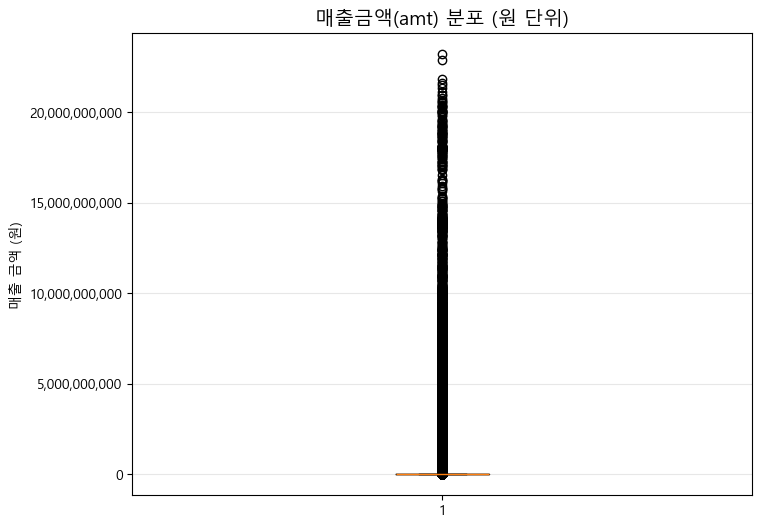

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. 그래프 생성
plt.figure(figsize=(8, 6))
plt.boxplot(df['amt'])

# 2. y축 단위 설정 (지수 표기법 끄고, 천 단위 쉼표 추가)
# ScalarFormatter를 사용해 지수 표기를 방지합니다.
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# 3. 그래프 꾸미기
plt.title("매출금액(amt) 분포 (원 단위)", fontsize=14)
plt.ylabel("매출 금액 (원)")
plt.grid(axis='y', alpha=0.3)

plt.show()